In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from VAE import VAE, kl_loss_function, mse_loss_function
from UNet import Unet
from DDPM_2D import Diffusion_Scheme

In [2]:
device = torch.device('cuda')
batch_size = 120
epochs = 30

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((32, 32)) 
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

In [4]:
def VAE_train(model, dataloader, optimizer, epochs):
    for epoch in range(epochs):
        mse_loss_sum = 0
        kl_loss_sum = 0
        loss_sum = 0
        
        pbar = tqdm(enumerate(dataloader), total=len(dataloader))
        pbar.set_description(f"Epoch {epoch} - Training")
        for i, batch in pbar:
            x, _ = batch
            x = x.to(device)
            mean, log_var = model.encoder(x)
            z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
            x_bar = model.decoder(z_sample).to(device)

            mse_loss = mse_loss_function(x, x_bar)
            kl_loss = kl_loss_function(mean, log_var)
            loss = torch.mean(mse_loss + kl_loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_loss_sum += mse_loss.item()
            kl_loss_sum += kl_loss.item()
            loss_sum += loss.item()
            pbar.set_postfix({'mse_loss' : mse_loss_sum / (i+1), 'kl_loss' : kl_loss_sum / (i+1), 'loss' : loss_sum /(i+1)})

    return model

In [5]:
model = VAE(image_channels=1, down_channels=[32, 64, 128], mid_channels=[128, 128],
            down_sample=[True, True], attn_down=[False, False], norm_channels=32, 
            num_heads=16,num_down_layers=1, num_mid_layers=1, num_up_layers=1, latent_channels=5).to(device)
optimizer = torch.optim.Adam(model.parameters())
model.train()
model = VAE_train(model, dataloader, optimizer, epochs=epochs)

Epoch 29 - Training: 100%|██████████| 500/500 [04:25<00:00,  1.89it/s, mse_loss=1.55e+3, kl_loss=1.64e+3, loss=3.19e+3]


In [6]:
torch.save(model.state_dict(), 'VAE_MNIST.pth')

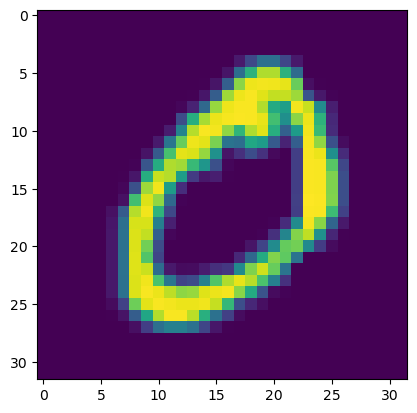

In [7]:
import matplotlib.pyplot as plt

x = dataloader.dataset[1][0].unsqueeze(0)
plt.imshow(x[0].permute(1, 2, 0))

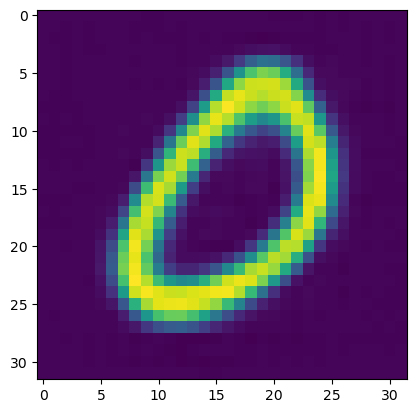

In [8]:
model.eval()

x = x.to(device)
mean, log_var = model.encoder(x)
z_sample = mean + torch.exp(0.5*log_var)*torch.randn(mean.shape).to(device)
x_bar = model.decoder(z_sample)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())

In [9]:
latent_images = []
labels = []

model.eval()
with torch.no_grad():
    for image, label in dataloader:
        image = image.to(device)
        mean, log_var = model.encoder(image)
        z = mean.to(device)
        latent_images.append(z)
        labels.append(label)

In [10]:
# Convertir listas a tensores
latent_images = torch.cat(latent_images)
labels = torch.cat(labels)

In [11]:
latent_images.shape, labels.shape

(torch.Size([60000, 5, 8, 8]), torch.Size([60000]))

In [12]:
from torch.utils.data import Dataset

class LatentDataset(Dataset):
    def __init__(self, latents, labels):
        self.latents = latents
        self.labels = labels

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.labels[idx]

# Crear el dataset con las codificaciones latentes
latent_mnist_dataset = LatentDataset(latent_images, labels)

In [13]:
from torch.utils.data import DataLoader, Subset

# Filtrar los índices de las muestras que pertenecen a la clase del 1
indices_clase_1 = [i for i, (img, label) in enumerate(latent_mnist_dataset) if label == 1]

# Crear un dataset con solo esos ejemplos (usando Subset)
latent_dataset_clase_1 = Subset(latent_mnist_dataset, indices_clase_1)

latent_dataloader = DataLoader(latent_dataset_clase_1, batch_size=32, shuffle=True)

In [18]:
unet = Unet(image_channels = latent_images.shape[1], down_channels = [128, 256, 256, 256], mid_channels = [256, 256], time_emb_dim = 256,
            down_sample = [False, False, False], num_down_layers = 2, num_mid_layers = 2, num_up_layers = 2, 
            attn_down = [True, True, True], norm_channels = 32, num_heads = 16, conv_out_channels = 128).to(device)
optimizer = optim.AdamW(unet.parameters(), lr=0.00001)
mse = nn.MSELoss()
diffusion = Diffusion_Scheme(image_size = latent_images.shape[2], device = device, timesteps = 1000, beta1 = 0.0015, betaT = 0.0195, beta_scheme = "linear")

for epoch in range(epochs):
    prog_bar = tqdm(dataloader)
    unet.train()
    for count, (images, _) in enumerate(prog_bar):
        images = images.to(device)
        t = diffusion.sample_timesteps(images.shape[0]).to(device)
        x_t, noise = diffusion.noise_images(images, t)
        predicted_noise = unet(x_t, t)
        loss = mse(noise, predicted_noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        prog_bar.set_postfix(MSE = loss.item())

TypeError: linspace() received an invalid combination of arguments - got (float, float, Diffusion_Scheme), but expected one of:
 * (Tensor start, Tensor end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Number start, Tensor end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Tensor start, Number end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (Number start, Number end, int steps, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [15]:
def sample_latent(diffusion_model, latent_dim, T):
    """
    Genera una muestra a partir de ruido puro.
    """
    with torch.no_grad():
        # Comenzar desde ruido puro
        z = torch.randn(1, latent_dim).to(device)

        # Revertir el proceso de difusión paso a paso
        for t in reversed(range(T)):
            t_tensor = torch.full((1,), t, dtype=torch.long).to(device)
            noise_pred = diffusion_model(z, t_tensor)
            z = (z - torch.sqrt(betas[t]) * noise_pred) / torch.sqrt(1 - betas[t])

    return z

In [16]:
z = sample_latent(diffusion_model, latent_dim, T)

In [ ]:
import matplotlib.pyplot as plt

model.eval()

x_bar = model.decoder(z)

plt.imshow(x_bar[0].permute(1, 2, 0).cpu().detach().numpy())